# Chroma Key

Neste projeto, será aplicado uma técnica de Chroma Key para substituir o fundo verde de uma 
imagem por um novo cenário. Duas imagens serão fornecidas: uma com uma ou mais pessoas sobre 
fundo verde e outra com o novo fundo (background). O objetivo é criar um script em Python, 
utilizando OpenCV, que isole a pessoa e insira corretamente o novo plano de fundo 



In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append('../')  

import funcoes 


import importlib
importlib.reload(funcoes)


<module 'funcoes' from 'c:\\Users\\dalto\\OneDrive\\Documentos\\Unifor\\Semestre 8\\ProcessamentoDigitalImagem\\AV2\\Projeto1_ChromeKey\\..\\funcoes.py'>

In [4]:
# Carrega a imagem rbg
img1_rgb = funcoes.carregar_imagem("projeto_1/img_fundo_verde_1.jpg", "rgb")
background_rgb = funcoes.carregar_imagem("projeto_1/background_1.png", "rgb")

img2_rgb = img1_rgb.copy()


# Carrregar imagem HSV
img1_HSV = cv2.cvtColor(img1_rgb, cv2.COLOR_RGB2HSV)

# Redimensiona a imagem de fundo
background = cv2.resize(background_rgb, (img2_rgb.shape[1], img2_rgb.shape[0]))


In [5]:
# Mascara para o verde
lower_green = np.array([36, 100, 100])
upper_green = np.array([85, 255, 255])

mask_green = cv2.inRange(img1_HSV, lower_green, upper_green)

# Máscara invertida
mask_not_green = cv2.bitwise_not(mask_green)

# Aplica a máscara invertida à imagem original (em RGB)
img1_SEG_not_green = cv2.bitwise_and(img2_rgb, img2_rgb, mask=mask_not_green)

# Aplica a máscara verde ao background (em RGB)
background_part = cv2.bitwise_and(background, background, mask=mask_green)

# Combina o objeto com o novo fundo
final_result = cv2.add(img1_SEG_not_green, background_part)




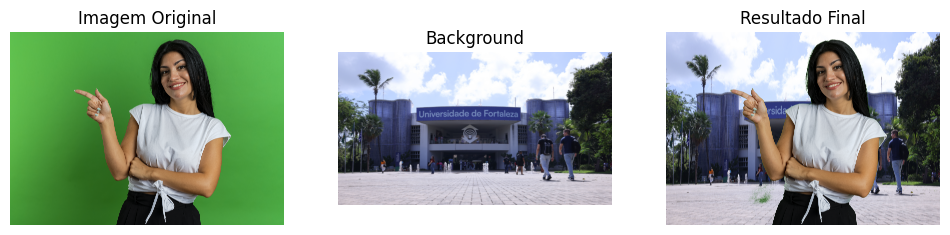

In [6]:

# Resultado
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
funcoes.exibir_imagem(img1_rgb, "Imagem Original")

plt.subplot(1, 3, 2)
funcoes.exibir_imagem(background_rgb, "Background")

plt.subplot(1, 3, 3)
funcoes.exibir_imagem(final_result, "Resultado Final")

plt.show()
